### User Simulation

In [71]:
import glob
import pandas as pd


models_of_interest = ["apertus-8b-instruct","apertus-70b-instruct"]

moi = models_of_interest[1]
# 1. Collect files
files = glob.glob("../../data/litellm/public.LiteLLM_SpendLogs/1/*.parquet")


df_list = []
for file in files:
    temp_df = pd.read_parquet(file)
    temp_df = temp_df[temp_df["model"] == moi]
    temp_df = temp_df[temp_df["status"] == "success"]

    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

# 2. Define the columns you want to KEEP
keep_cols = [
    "end_user",
    "startTime",
    "endTime",
    "completionStartTime",
    "prompt_tokens",
    "completion_tokens",
    "total_tokens",
]

# Keep ONLY those (ignore missing if any file doesn't have it)
df = df[[c for c in keep_cols if c in df.columns]].copy()

# 3. Parse timestamps and sort
df["startTime"] = pd.to_datetime(df["startTime"],format = "mixed")
df["completionStartTime"] = pd.to_datetime(df["completionStartTime"],format = "mixed")
df["endTime"] = pd.to_datetime(df["endTime"],format = "mixed")
df = df.sort_values("startTime")

# df["TTFT_latency"] = (df["completionStartTime"] - df["startTime"]).dt.total_seconds()
# df["Decode_latency"] = (df["endTime"] - df["completionStartTime"]).dt.total_seconds()
# df["latency"] = (df["endTime"] - df["startTime"]).dt.total_seconds()
# # 4. Compute inter-arrival times (Δ between current and previous request)
# df["interarrival_seconds"] = df["startTime"].diff().dt.total_seconds()


print(df.shape)
df.tail() ## no day is multiple times since it starts 02.09. and ends 01.10. so its exactly one month

idx_real = [1,4,5]


(103729, 7)


In [61]:
import sys
sys.path.append("..")  # or the path to your project root
from configs.usage_simulation_config import * 
from usage_simulation import *
from scipy.stats import lognorm
import pandas as pd
import matplotlib.pyplot as plt

cfg = UsageSimulationCfg(
    days = 1,
    hour_peak= 12,
    num_users= 20000,
    daily_prompts= 3,
    median_prompt_tokens= 1200,
    start_date=pd.Timestamp(year=2025,month=9,day=4)
)

sim = UsageSimulation(cfg)

df_ = sim.simulate()

idx_sim = [0,1,2]


### Latency Simulation

In [72]:
from configs.computation_config import *
from computation_simulation import *
import pandas as pd
import numpy as np
import glob
import os

#df_day = df_
df_day = df[df["startTime"].dt.floor("D") == pd.Timestamp("2025-09-04")]

cfg = ComputeSimulationCfg("../configs/cluster_configs.json",16,0.1,util_f=lambda b: min(1,b/25.0))

cfg.cluster_cfgs = cfg.cluster_cfgs
print(cfg.cluster_cfgs)
print(df_day.head(3))

sim = ComputeSimulation(cfg)

dfs= sim.simulate(df_day,*idx_real)
full_dfs = []
print("----------------------------")
for df in dfs:
    print(df.head(3))
    print("-----------------------------------------------")
    full_df = sim.concat(df_day,df)
    full_dfs.append(full_df)

Model A100_8x40GB_p4d_replica1 instantiated:
 - 1 replicas
 - Cluster price per hour: 32.77
Model A100_8x40GB_p4d_replica2 instantiated:
 - 2 replicas
 - Cluster price per hour: 64.00
Model A100_8x40GB_p4d_replica4 instantiated:
 - 4 replicas
 - Cluster price per hour: 126.00
Model H100_8x80GB_p5_replica1 instantiated:
 - 1 replicas
 - Cluster price per hour: 98.32
Model H100_8x80GB_p5_replica2 instantiated:
 - 2 replicas
 - Cluster price per hour: 196.00
Model H100_8x80GB_p5_replica4 instantiated:
 - 4 replicas
 - Cluster price per hour: 362.00
[ComputeCluster(name='A100_8x40GB_p4d_replica1', num_replicas=1, num_gpu_per_replica=8, gpu_vram_B=40000000000, model_size_B=140000000000, peak_prefill_tks_per_sec_per_replica=10000, peak_decode_tks_per_sec_per_replica=1000, price_per_hour=32.77, is_price_monthly=False), ComputeCluster(name='A100_8x40GB_p4d_replica2', num_replicas=2, num_gpu_per_replica=8, gpu_vram_B=40000000000, model_size_B=140000000000, peak_prefill_tks_per_sec_per_replica=1

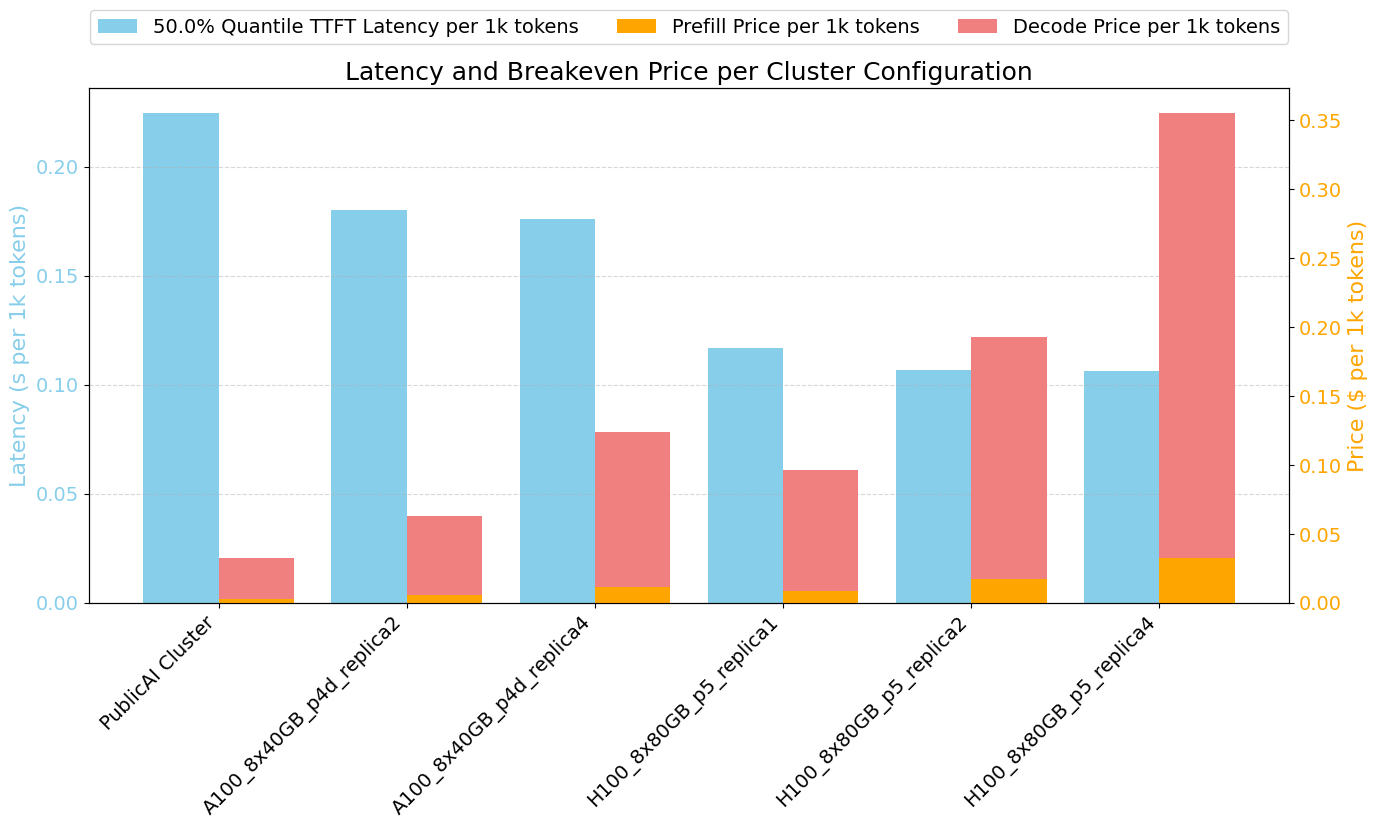

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# --- Compute metrics per cluster ---
# ----------------------------
latencies = []
prefill_prices = []
decode_prices = []

R = 10  # Completion token multiplier
Q = 0.5
# Compute totals over the day (same for all clusters)
prompt_tks = df_day["prompt_tokens"].sum()
comp_tks = df_day["completion_tokens"].sum()

true_prefill_price_1K = None
true_decode_price_1K = None

for full_df, cfg_cluster in zip(full_dfs, cfg.cluster_cfgs):
    df_f = full_df.copy()

    # TTFT latency per request
    df_f["TTFT_latency_est"] = (df_f["prefillTime"] - df_f["startTime"]).dt.total_seconds()
    median_latency_per_1K = 1e3 * (df_f["TTFT_latency_est"] / df_f["prompt_tokens"]).quantile(Q)

    # Price computation
    prefill_tk_price = cfg_cluster.price_per(days=1) / (R * comp_tks + prompt_tks)
    prefill_price_1K = prefill_tk_price * 1e3
    decode_price_1K = prefill_tk_price * 1e3 * R

    # Append metrics
    latencies.append(median_latency_per_1K)
    prefill_prices.append(prefill_price_1K)
    decode_prices.append(decode_price_1K)

    # Store baseline prices for plotting stacked bars
    if true_prefill_price_1K is None:
        true_prefill_price_1K = prefill_price_1K
        true_decode_price_1K = decode_price_1K

# ----------------------------
# --- Prepare plotting ---
# ----------------------------
cfg_names = [c.name for c in cfg.cluster_cfgs]
cfg_names[0] = "PublicAI Cluster"

x = np.arange(len(cfg_names))
width = 0.4

# Set a larger base font size
plt.rcParams.update({'font.size': 14})

fig, ax1 = plt.subplots(figsize=(14, 8))

# Latency bars
bars_latency = ax1.bar(
    x - width/2, latencies, width,
    color='skyblue', label=f'{Q*100}% Quantile TTFT Latency per 1k tokens'
)
ax1.set_ylabel('Latency (s per 1k tokens)', color='skyblue', fontsize=16)
ax1.tick_params(axis='y', labelcolor='skyblue', labelsize=14)
ax1.tick_params(axis='x', labelsize=14)

# Add horizontal gridlines for latency
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Price bars (stacked)
ax2 = ax1.twinx()
bars_prefill = ax2.bar(
    x + width/2, prefill_prices, width,
    color='orange', label='Prefill Price per 1k tokens'
)
bars_decode = ax2.bar(
    x + width/2, decode_prices, width,
    bottom=prefill_prices,
    color='lightcoral', label='Decode Price per 1k tokens'
)
ax2.set_ylabel('Price ($ per 1k tokens)', color='orange', fontsize=16)
ax2.tick_params(axis='y', labelcolor='orange', labelsize=14)

# X-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(cfg_names, rotation=45, ha='right', fontsize=14)

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
fig.legend(handles1 + handles2, labels1 + labels2,
           loc='upper center', ncol=len(cfg_names), bbox_to_anchor=(0.5, 1.05), fontsize=14)

plt.title("Latency and Breakeven Price per Cluster Configuration", fontsize=18)
plt.tight_layout()
plt.show()


In [83]:

df_comp = full_dfs[0]

df_comp["prefill_e"] = (df_comp["prefillTime"] - df_comp["completionStartTime"]).dt.total_seconds() 
df_comp["decode_e"] = (df_comp["decodeTime"] - df_comp["endTime"]).dt.total_seconds() 

In [87]:
print("median prefill error:",df_comp["prefill_e"].median())
print("mean prefill error:",df_comp["prefill_e"].mean())
print("std prefill error:",df_comp["prefill_e"].std())
print("median prefill error:",df_comp["decode_e"].median())
print("mean prefill error:",df_comp["decode_e"].mean())
print("std prefill error:",df_comp["decode_e"].std())

median prefill error: -0.043
mean prefill error: -12.858647660818715
std prefill error: 175.29387101543128
median prefill error: -0.963
mean prefill error: -20.00923245614035
std prefill error: 188.34635515902878
